<a href="https://colab.research.google.com/github/Shivabairy005/Deep-Learning-Lab/blob/main/DL_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Learning Rate vs Final Loss:
0.0001 -> 0.252278
0.001 -> 0.250332
0.01 -> 0.249944
0.05 -> 0.248885
0.1 -> 0.234782
0.5 -> 0.010789
1.0 -> 0.001663


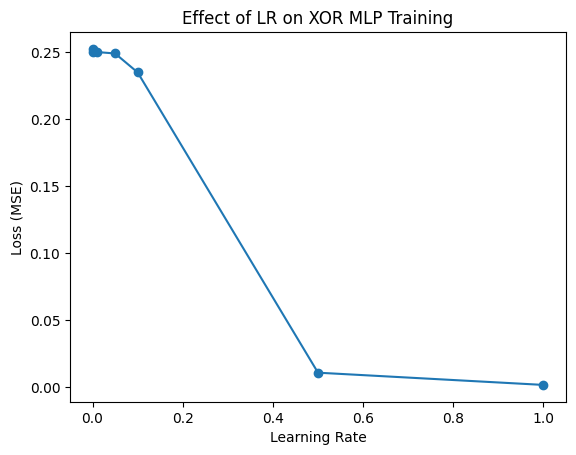

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

def sigmoid(n):
    return 1 / (1 + np.exp(-n))

def sigmoid_derivative(n):
    return n * (1 - n)

lr_list = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
losses = []
epochs = 1000

for lr in lr_list:
    w1 = np.random.randn(2, 8) * 0.5
    b1 = np.random.randn(1, 8) * 0.1
    w2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1, 1) * 0.1

    for _ in range(epochs):
        hidden_input = np.dot(X, w1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, w2) + b2
        y_pred = sigmoid(final_input)

        error = y - y_pred
        loss = np.mean(error ** 2)

        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(w2.T) * sigmoid_derivative(hidden_output)

        w2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        w1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    losses.append(loss)

print("Learning Rate vs Final Loss:")
for lr, loss in zip(lr_list, losses):
    print(f"{lr} -> {loss:.6f}")

plt.figure()
plt.plot(lr_list, losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss (MSE)")
plt.title("Effect of LR on XOR MLP Training")
plt.show()

In [2]:
import numpy as np

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(n):
    return n * (1 - n)

input_neurons = 2
hidden_neurons = 4
output_neurons = 1

np.random.seed(42)
w1 = np.random.randn(input_neurons, hidden_neurons)
b1 = np.zeros((1, hidden_neurons))
w2 = np.random.randn(hidden_neurons, output_neurons)
b2 = np.zeros((1, output_neurons))

lr = 0.1
epochs = 1000

for _ in range(epochs):
    h_input = X @ w1 + b1
    h_output = sigmoid(h_input)

    final_input = h_output @ w2 + b2
    y_pred = sigmoid(final_input)

    loss = np.mean((y - y_pred) ** 2)

    error = y - y_pred
    d_output = error * sigmoid_derivative(y_pred)

    error_hidden = d_output @ w2.T
    d_hidden = error_hidden * sigmoid_derivative(h_output)

    w2 += h_output.T @ d_output * lr
    b2 += np.sum(d_output, axis=0, keepdims=True) * lr
    w1 += X.T @ d_hidden * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

print("Final Loss:", loss)
print("Predictions:")
print(y_pred)

Final Loss: 0.2452382426313351
Predictions:
[[0.47493319]
 [0.52121391]
 [0.50114096]
 [0.52658805]]


In [3]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Perceptron(eta0=0.1, random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8


In [4]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=20,
    random_state=1
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.964952380952381
